In [1]:
# !pip install opencv-python==4.9.0.80 tqdm matplotlib
# 

In [2]:
# import kagglehub
# path = kagglehub.dataset_download("wongjitchow/mouth-yawn-split")

# print("Path to dataset files:", path)


import tensorflow as tf

# ตั้งค่า GPU ให้ยืดหยุ่น
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)



2025-10-22 18:37:57.420616: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-22 18:37:57.435406: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-22 18:37:57.452433: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-22 18:37:57.457662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-22 18:37:57.471248: I tensorflow/core/platform/cpu_feature_guar

In [3]:
import cv2
import os
from os import listdir
from os.path import join    
import numpy as np  
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2   
from keras.models import Sequential , load_model
from keras.layers import Dense, Dropout, Activation, Flatten , Conv2D, MaxPool2D,MaxPooling2D
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import glob
import math
import time
import threading
print("Tensorflow version " + tf.__version__)
# print("Keras version " + tf.keras.__version__)
print("OpenCV version " + cv2.__version__)
print(MobileNetV2)
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


Tensorflow version 2.17.0
OpenCV version 4.9.0
<function MobileNetV2 at 0x787fece6ba60>
2.17.0
Num GPUs Available:  1
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 10559195961840356668
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 2950692864
locality {
  bus_id: 1
  links {
  }
}
incarnation: 11113045328058878358
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0"
xla_global_id: 416903419
]


I0000 00:00:1761158280.057944   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158280.058006   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158280.058018   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158280.191429   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158280.191476   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-22

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. Training will use CPU.")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


(<Axes: >, <matplotlib.image.AxesImage at 0x787d58063f50>)

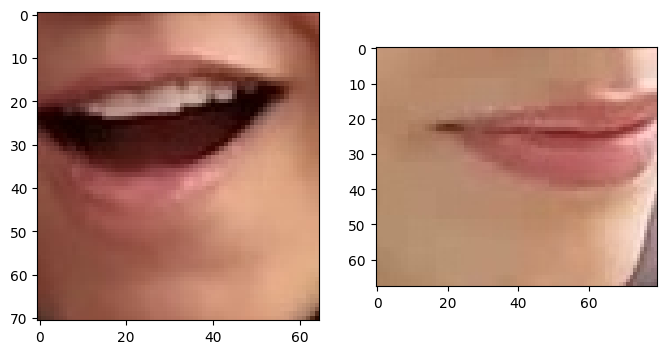

In [5]:
yawn_dir = 'yawn'
not_yawn_dir = 'no_yawn'
image_size = 256

img1 = cv2.imread('yawn/assets/images/train/yawn/1.jpg')
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread('yawn/assets/images/train/no-yawn/2760.jpg')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)

In [6]:
train_path = 'yawn/assets/images/train/'
test_path = 'yawn/assets/images/test/'

trainImg = [train_path+f for f in listdir(train_path)]
testImg = [test_path+f for f in listdir(test_path)]

In [7]:
trainImg , testImg

(['yawn/assets/images/train/no-yawn',
  'yawn/assets/images/train/yawn',
  'yawn/assets/images/train/.ipynb_checkpoints'],
 ['yawn/assets/images/test/no-yawn',
  'yawn/assets/images/test/yawn',
  'yawn/assets/images/test/.ipynb_checkpoints'])

In [8]:
def img2data(path):
    rawImgs = []
    labels = []

    for imagePath in (path):
        print(imagePath)
        for item in tqdm(listdir(imagePath)):
            file = join(imagePath, item)
            if file[-1] =='g':
                img = cv2.imread(file , cv2.COLOR_BGR2RGB)
                img = cv2.resize(img ,(image_size,image_size))
                rawImgs.append(img)
            
                l = imagePath.split('/')[-1]
                if l == 'no-yawn':
                    labels.append([1,0])         
                elif l == 'yawn':
                    labels.append([0,1])
            
    return rawImgs, labels

In [9]:
x_train, y_train = img2data(trainImg)
x_test, y_test = img2data(testImg)

yawn/assets/images/train/no-yawn


100%|██████████| 2591/2591 [00:00<00:00, 3196.90it/s]


yawn/assets/images/train/yawn


100%|██████████| 2528/2528 [00:00<00:00, 3305.33it/s]


yawn/assets/images/train/.ipynb_checkpoints


...

100%|██████████| 322/322 [00:00<00:00, 3423.60it/s]


yawn/assets/images/test/yawn


100%|██████████| 758/758 [00:00<00:00, 3331.79it/s]


yawn/assets/images/test/.ipynb_checkpoints


0it [00:00, ?it/s]


In [10]:
x_train = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY), (image_size, image_size)) for image in x_train])
y_train = np.array(y_train)
x_test = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_BGR2GRAY), (image_size, image_size)) for image in x_test])
y_test = np.array(y_test)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [11]:
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((5119, 256, 256), (5119, 2), (1080, 256, 256), (1080, 2))

In [12]:
train_data_path = 'yawn/assets/images/train'
batch_size = 16

# train_datagen = ImageDataGenerator(horizontal_flip = True, 
#                                   rescale = 1./255, 
#                                   zoom_range = 0.2, 
#                                   validation_split = 0.1)

# train_generator = train_datagen.flow_from_directory(
#     train_data_path,
#     target_size=(image_size, image_size),
#     batch_size=batch_size,
#     color_mode='grayscale',
#     class_mode='binary',
#     subset='training'
# )

# validation_generator = train_datagen.flow_from_directory(
#     train_data_path,
#     target_size=(image_size, image_size),
#     batch_size=batch_size,
#     color_mode='grayscale',
#     class_mode='binary',
#     subset='validation'
# )

In [13]:
classes = 2

layers_list = [
    Conv2D(32, (3,3), padding='same', input_shape=(256,256,1), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(classes, activation='softmax')
]

model = Sequential(layers_list)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761158285.726901   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158285.726999   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158285.727013   24170 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1761158285.727210   24170 cuda_executor.cc:1001] 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,481,474 (32.35 MB)

 Trainable params: 8,481,474 (32.35 MB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
model.compile(loss = 'categorical_crossentropy',optimizer = 'adam' , metrics = ['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [15]:

num_epochs = 30

history = model.fit(
            x_train,y_train,
            epochs=num_epochs,
            validation_data=(x_test,y_test),
            callbacks=[early_stop],
            batch_size=16
        )        


Epoch 1/30


I0000 00:00:1761158292.166788   24380 service.cc:146] XLA service 0x787c4c004c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761158292.166861   24380 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2025-10-22 18:38:12.191344: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-22 18:38:12.349111: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
2025-10-22 18:38:12.953999: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 18:38:13.019063: W external/local_tsl/tsl/framework/bfc_allocator.cc:29

 10/320 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5113 - loss: 0.9684

I0000 00:00:1761158294.562425   24380 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


319/320 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7884 - loss: 0.4793

...

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7886 - loss: 0.4789

2025-10-22 18:38:22.765388: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-22 18:38:22.831023: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2025-10-22 18:38:23.630886: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.15GiB with freed

320/320 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7889 - loss: 0.4785 - val_accuracy: 0.9259 - val_loss: 0.1873
Epoch 2/30
  1/320 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 1.0000 - loss: 0.0213

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9297 - loss: 0.1899 - val_accuracy: 0.9556 - val_loss: 0.1234
Epoch 3/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9583 - loss: 0.1249 - val_accuracy: 0.9778 - val_loss: 0.0635
Epoch 4/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9647 - loss: 0.0945 - val_accuracy: 0.9806 - val_loss: 0.0529
Epoch 5/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9814 - loss: 0.0594 - val_accuracy: 0.9852 - val_loss: 0.0412
Epoch 6/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9841 - loss: 0.0571 - val_accuracy: 0.9898 - val_loss: 0.0246
Epoch 7/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9963 - val_loss: 0.0129
Epoch 8/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9935 - loss: 0.0195 - val_accuracy: 0.9898 - val_loss: 0.0234
Epoch 9/30
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9941 - loss: 0.0184 - val_accuracy: 0.992